<a href="https://colab.research.google.com/github/simplemangwiro-collab/compmathshtml/blob/main/GEOFF%20MID%20TERM%20PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intraday Moving Average Crossover Strategy on QQQ

This project designs and implements an intraday trading strategy using 5-minute market data for the QQQ ETF.

The strategy uses two technical indicators:

MA5 – short-term moving average  
MA20 – long-term moving average  

Trading Rules:

Buy when MA5 > MA20  
Sell when MA5 < MA20  

Signals are shifted by one period to avoid look-ahead bias in the backtest.

The strategy is evaluated over one week of intraday data using performance metrics such as total return, number of trades, and win rate.

## Data Source

Market data was obtained using the Python library yfinance.

The dataset contains 5-minute interval price data for the QQQ ETF, including:

Open  
High  
Low  
Close  
Volume

## Strategy Performance

The strategy was evaluated using a simple backtest.

Performance metrics calculated include:

Total Strategy Return  
Market Return  
Number of Trades  
Win Rate  

These metrics allow comparison between the algorithmic strategy and the underlying market performance.

In [16]:
!pip install yfinance

In [17]:
import yfinance as yf
import pandas as pd

data = yf.download("QQQ", period="7d", interval="5m")
print(data.head())

/tmp/ipykernel_814/1226831206.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("QQQ", period="7d", interval="5m")
[*********************100%***********************]  1 of 1 completed

Price                           Close        High         Low        Open  \
Ticker                            QQQ         QQQ         QQQ         QQQ   
Datetime                                                                    
2026-03-09 13:30:00+00:00  595.320007  596.460022  594.030029  594.219971   
2026-03-09 13:35:00+00:00  593.419983  595.673523  593.270020  595.309998   
2026-03-09 13:40:00+00:00  593.010010  593.630005  592.309998  593.409973   
2026-03-09 13:45:00+00:00  592.489990  593.880005  592.090027  592.979980   
2026-03-09 13:50:00+00:00  592.000000  592.960022  591.510010  592.500000   

Price                       Volume  
Ticker                         QQQ  
Datetime                            
2026-03-09 13:30:00+00:00  5652456  
2026-03-09 13:35:00+00:00  1365878  
2026-03-09 13:40:00+00:00  1748333  
2026-03-09 13:45:00+00:00  1601095  
2026-03-09 13:50:00+00:00  1644216  


In [18]:
# Calculate moving averages
data['MA5'] = data['Close'].rolling(window=5).mean()
data['MA20'] = data['Close'].rolling(window=20).mean()

# Show the first 25 rows so we can see the averages appear
print(data[['Close', 'MA5', 'MA20']].head(25))

Price                           Close         MA5        MA20
Ticker                            QQQ                        
Datetime                                                     
2026-03-09 13:30:00+00:00  595.320007         NaN         NaN
2026-03-09 13:35:00+00:00  593.419983         NaN         NaN
2026-03-09 13:40:00+00:00  593.010010         NaN         NaN
2026-03-09 13:45:00+00:00  592.489990         NaN         NaN
2026-03-09 13:50:00+00:00  592.000000  593.247998         NaN
2026-03-09 13:55:00+00:00  592.729980  592.729993         NaN
2026-03-09 14:00:00+00:00  595.090027  593.064001         NaN
2026-03-09 14:05:00+00:00  593.109619  593.083923         NaN
2026-03-09 14:10:00+00:00  592.390015  593.063928         NaN
2026-03-09 14:15:00+00:00  593.260010  593.315930         NaN
2026-03-09 14:20:00+00:00  594.760010  593.721936         NaN
2026-03-09 14:25:00+00:00  593.469971  593.397925         NaN
2026-03-09 14:30:00+00:00  594.119995  593.600000         NaN
2026-03-

In [19]:
# Generate trading signals
data['signal'] = 0

# Buy signal
data.loc[data['MA5'] > data['MA20'], 'signal'] = 1

# Sell signal
data.loc[data['MA5'] < data['MA20'], 'signal'] = -1

# Show the signals
print(data[['Close','MA5','MA20','signal']].tail(20))

Price                           Close         MA5        MA20 signal
Ticker                            QQQ                               
Datetime                                                            
2026-03-16 19:50:00+00:00  599.905029  600.164612  601.101730     -1
2026-03-16 19:55:00+00:00  600.309998  600.126611  601.044730     -1
2026-03-17 13:30:00+00:00  604.539978  600.959009  601.195728     -1
2026-03-17 13:35:00+00:00  604.919983  601.937000  601.364227      1
2026-03-17 13:40:00+00:00  604.664978  602.867993  601.528476      1
2026-03-17 13:45:00+00:00  605.870728  604.061133  601.741513      1
2026-03-17 13:50:00+00:00  605.630005  605.125134  601.932513      1
2026-03-17 13:55:00+00:00  605.359985  605.289136  602.115012      1
2026-03-17 14:00:00+00:00  604.729980  605.251135  602.283762      1
2026-03-17 14:05:00+00:00  604.659973  605.250134  602.459259      1
2026-03-17 14:10:00+00:00  603.770020  604.829993  602.593759      1
2026-03-17 14:15:00+00:00  604.450

In [20]:
# Calculate market returns
data['returns'] = data['Close'].pct_change()

# Shift signal by 1 so we use the previous signal to trade the next bar
data['strategy_returns'] = data['signal'].shift(1) * data['returns']

# Cumulative returns
data['cumulative_market'] = (1 + data['returns']).cumprod()
data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()

# Show the last rows
print(data[['Close', 'signal', 'returns', 'strategy_returns', 'cumulative_strategy']].tail(20))

Price                           Close signal   returns strategy_returns  \
Ticker                            QQQ                                     
Datetime                                                                  
2026-03-16 19:50:00+00:00  599.905029     -1 -0.000175         0.000175   
2026-03-16 19:55:00+00:00  600.309998     -1  0.000675        -0.000675   
2026-03-17 13:30:00+00:00  604.539978     -1  0.007046        -0.007046   
2026-03-17 13:35:00+00:00  604.919983      1  0.000629        -0.000629   
2026-03-17 13:40:00+00:00  604.664978      1 -0.000422        -0.000422   
2026-03-17 13:45:00+00:00  605.870728      1  0.001994         0.001994   
2026-03-17 13:50:00+00:00  605.630005      1 -0.000397        -0.000397   
2026-03-17 13:55:00+00:00  605.359985      1 -0.000446        -0.000446   
2026-03-17 14:00:00+00:00  604.729980      1 -0.001041        -0.001041   
2026-03-17 14:05:00+00:00  604.659973      1 -0.000116        -0.000116   
2026-03-17 14:10:00+00:00

In [21]:
# Total strategy return
total_return = data['cumulative_strategy'].iloc[-1] - 1

# Total market return
market_return = data['cumulative_market'].iloc[-1] - 1

# Number of trades (signal changes)
trades = data['signal'].diff().abs().sum()

# Win rate
wins = data[data['strategy_returns'] > 0].shape[0]
losses = data[data['strategy_returns'] < 0].shape[0]

win_rate = wins / (wins + losses)

print("Strategy Return:", total_return)
print("Market Return:", market_return)
print("Number of Trades:", trades)
print("Win Rate:", win_rate)

Strategy Return: -0.042576290672236894
Market Return: 0.01631059237585708
Number of Trades: 73.0
Win Rate: 0.48156182212581344


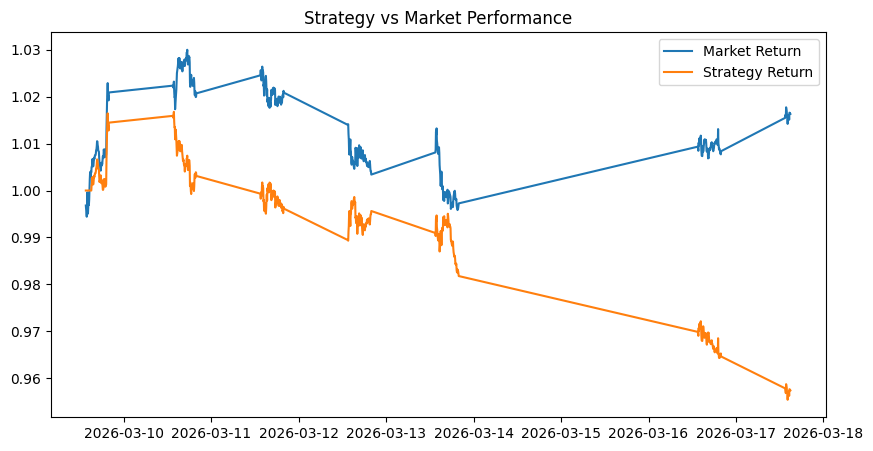

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data['cumulative_market'], label='Market Return')
plt.plot(data['cumulative_strategy'], label='Strategy Return')
plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()

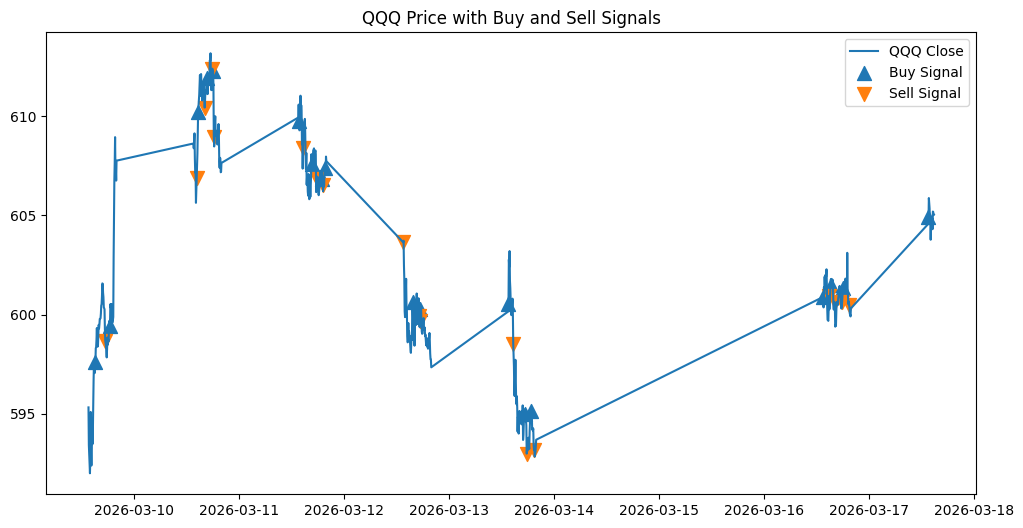

In [23]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label='QQQ Close')

buy_signals = data[(data['signal'] == 1) & (data['signal'].shift(1) != 1)]
sell_signals = data[(data['signal'] == -1) & (data['signal'].shift(1) != -1)]

plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', s=100, label='Buy Signal')
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', s=100, label='Sell Signal')

plt.title('QQQ Price with Buy and Sell Signals')
plt.legend()
plt.show()